# Microestructura y Alta Frecuencia en Python
### Clase 8: Práctica (2 h)
**Finanzas Cuantitativas, la Ciencia y los Mercados**
FCEN-UBA · Guido Schifani

---

| Ejercicio | Tema | Qué hacemos |
|---|---|---|
| **1** | Anatomía real del libro de AAPL | Spread, profundidad, random walk, Roll y λ de Kyle — TODO sobre el libro real |
| **2** | Avellaneda-Stoikov vs. el MM ingenuo | Cotizando sobre el camino REAL del mid de AAPL, con fills contra trades reales |
| **3** | Impacto y ejecución, calibrados | La square-root law (ingenua vs. correcta) + Almgren-Chriss con σ y λ reales de AAPL |
| *Extra* | Hawkes en el order flow real | Branching ratio por MLE sobre los ~114k trades reales de AAPL del día |



In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, brentq
import warnings
warnings.filterwarnings('ignore')

NAVY, VIOLET, ORANGE = '#1E1B4B', '#4B3FA0', '#E8602C'
GREEN, RED, MGRAY = '#2E7D32', '#C62828', '#8A8A9A'
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.facecolor': '#F4F4F7', 'figure.facecolor': 'white'})

DATOS_BOOK = os.path.join('..', 'datos_microestructura', 'book')
DATOS_TRADES = os.path.join('..', 'datos_microestructura', 'trades')

book = pd.read_parquet(os.path.join(DATOS_BOOK, 'AAPL_mbp10_2026-08-06.parquet'))
trades = pd.read_parquet(os.path.join(DATOS_TRADES, 'AAPL_trades_2026-08-06.parquet'))
book = book[~book.index.duplicated(keep='last')]
print(f'Libro: {len(book):,} snapshots, {book.index.min()} a {book.index.max()}')
print(f'Trades: {len(trades):,}, {trades.index.min()} a {trades.index.max()}')

Libro: 725,846 snapshots, 2026-08-06 13:30:00.020619917+00:00 a 2026-08-06 14:59:59.938293071+00:00
Trades: 157,011, 2026-08-06 13:30:00.020619917+00:00 a 2026-08-06 19:59:59.990504504+00:00


---
# Ejercicio 1: Anatomía real del libro de AAPL

## La idea

Miramos el libro de órdenes REAL de AAPL (§1-§2 de la teórica) y
chequeamos, con datos, las preguntas que la teórica dejó planteadas:

- ¿Cuánto vale el spread, y es estable en el tiempo o varía mucho?
- ¿Cómo es la profundidad del libro nivel a nivel?
- ¿El mid se comporta como un random walk (autocorrelación ≈0 de sus incrementos)?
- La regresión de **Kyle** ($\Delta p = \lambda \cdot y + \varepsilon$, con $y$ el flujo
  firmado) — ¿predice el precio? ¿Y si le destruimos el orden temporal al flujo (un
  "placebo" armado con la MISMA cinta real, solo barajada)?

In [2]:
mid = (book['bid_px_00'] + book['ask_px_00']) / 2
spread = book['ask_px_00'] - book['bid_px_00']
spread = spread[(spread > 0) & (spread < 1)]

print(f'Spread medio del día: ${spread.mean():.4f}   (mediana ${spread.median():.4f})')
print(f'Spread en los primeros 2 min: ${spread.iloc[:2000].mean():.4f}  (vs. último tercio: ${spread.iloc[-len(spread)//3:].mean():.4f})')

depth_bid = book[[f'bid_sz_{i:02d}' for i in range(10)]].mean()
depth_ask = book[[f'ask_sz_{i:02d}' for i in range(10)]].mean()
print(f'\\nProfundidad nivel 0 (mejor precio): bid={depth_bid.iloc[0]:.0f}  ask={depth_ask.iloc[0]:.0f} acciones')
print(f'Profundidad nivel 9 (10mo nivel):    bid={depth_bid.iloc[9]:.0f}  ask={depth_ask.iloc[9]:.0f} acciones')

micro = (book['bid_px_00']*book['ask_sz_00'] + book['ask_px_00']*book['bid_sz_00']) / (book['bid_sz_00']+book['ask_sz_00'])
diff_bp = (micro - mid) / mid * 1e4
print(f'\\nMicroprecio vs. mid: diferencia media {diff_bp.mean():.3f} bps (std {diff_bp.std():.3f} bps)')

Spread medio del día: $0.0526   (mediana $0.0400)
Spread en los primeros 2 min: $0.1157  (vs. último tercio: $0.0389)
\nProfundidad nivel 0 (mejor precio): bid=134  ask=93 acciones
Profundidad nivel 9 (10mo nivel):    bid=177  ask=163 acciones
\nMicroprecio vs. mid: diferencia media 0.064 bps (std 0.588 bps)


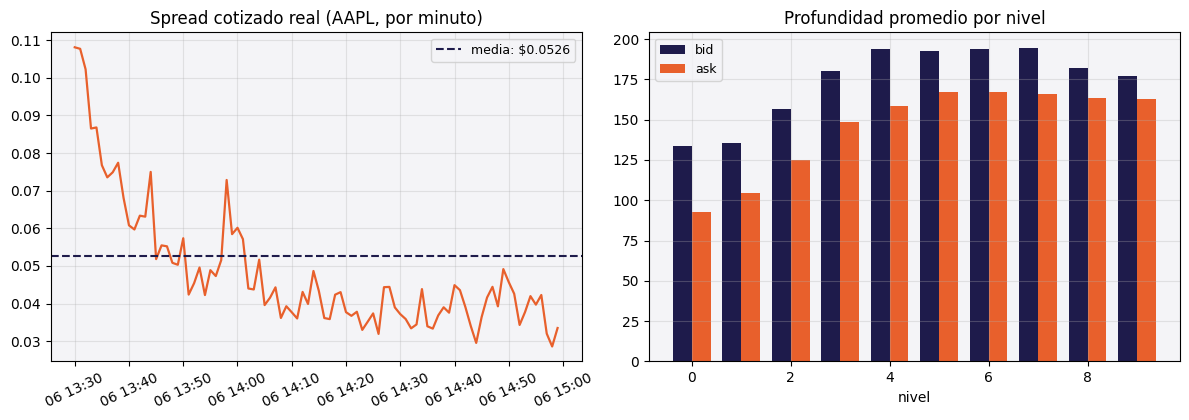

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
sp_1min = spread.resample('1min').mean()
axes[0].plot(sp_1min.index, sp_1min.values, color=ORANGE, lw=1.6)
axes[0].axhline(spread.mean(), color=NAVY, ls='--', label=f'media: ${spread.mean():.4f}')
axes[0].set_title('Spread cotizado real (AAPL, por minuto)'); axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=25)

niveles = np.arange(10); w = 0.38
axes[1].bar(niveles - w/2, depth_bid.values, width=w, color=NAVY, label='bid')
axes[1].bar(niveles + w/2, depth_ask.values, width=w, color=ORANGE, label='ask')
axes[1].set_title('Profundidad promedio por nivel'); axes[1].set_xlabel('nivel'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

In [4]:
print('¿Random walk? Autocorrelación lag-1 de los incrementos del mid, a varias frecuencias:')
for freq in ['1s', '5s', '15s', '30s', '60s']:
    m = mid.resample(freq).last().ffill()
    dm = m.diff().dropna()
    print(f'  {freq:>4s}:  autocorr = {dm.autocorr(1):+.4f}   (n={len(dm)})')

# Estimador de Roll: spread implicito = 2*sqrt(-cov(dp_t, dp_t-1)), trade a trade
dp = trades['price'].diff().dropna()
cov1 = np.cov(dp[:-1], dp[1:])[0, 1]
roll = 2*np.sqrt(-cov1) if cov1 < 0 else np.nan
print(f'\\nEstimador de Roll (implícito, trade a trade): ${roll:.4f}')
print(f'Spread REAL cotizado (promedio del día):        ${spread.mean():.4f}')
print(f'Roll subestima por un factor {spread.mean()/roll:.1f}x — el flujo real NO es i.i.d. (ver el Extra, Hawkes)')

¿Random walk? Autocorrelación lag-1 de los incrementos del mid, a varias frecuencias:
    1s:  autocorr = -0.0156   (n=5399)
    5s:  autocorr = +0.0472   (n=1079)
   15s:  autocorr = -0.0240   (n=359)
   30s:  autocorr = +0.0114   (n=179)
   60s:  autocorr = -0.1588   (n=89)
\nEstimador de Roll (implícito, trade a trade): $0.0049
Spread REAL cotizado (promedio del día):        $0.0526
Roll subestima por un factor 10.8x — el flujo real NO es i.i.d. (ver el Extra, Hawkes)


### λ de Kyle: real vs. placebo

Repetimos la regresión de Kyle a varias frecuencias de agregación, y la comparamos contra
un **placebo**: la MISMA cinta de trades reales, con el flujo firmado barajado al azar en
el tiempo. No inventamos ningún dato nuevo — solo le rompemos al flujo real la única cosa
que importa para la regresión: el orden temporal.

In [5]:
tr = trades[trades['side'].isin(['A', 'B'])].copy()
sz = tr['size'].astype(np.int64)              # ¡cuidado! size es uint32, -size sin castear desborda
signed = np.where(tr['side'] == 'B', sz, -sz)
of_real = pd.Series(signed, index=tr.index)

rng = np.random.default_rng(0)
shuf = signed.copy(); rng.shuffle(shuf)
of_placebo = pd.Series(shuf, index=tr.index)

def kyle(freq, of_s):
    m = mid.resample(freq).last().ffill()
    dp = m.diff().dropna()
    of = of_s.resample(freq).sum()
    df = pd.concat([dp, of], axis=1, keys=['dp', 'of']).dropna()
    b, a = np.polyfit(df['of'], df['dp'], 1)
    r2 = 1 - ((df['dp'] - (a + b*df['of']))**2).sum() / ((df['dp']-df['dp'].mean())**2).sum()
    return b, r2, len(df)

print('λ de Kyle — REAL:')
for freq in ['1s', '5s', '15s', '60s']:
    b, r2, n = kyle(freq, of_real)
    print(f'  {freq:>4s}:  λ={b:.2e} $/acción   R²={r2:.3f}   (n={n})')
print('\\nλ de Kyle — PLACEBO (mismo flujo, orden barajado):')
for freq in ['1s', '5s', '15s', '60s']:
    b, r2, n = kyle(freq, of_placebo)
    print(f'  {freq:>4s}:  λ={b:.2e} $/acción   R²={r2:.3f}   (n={n})')

λ de Kyle — REAL:
    1s:  λ=2.07e-05 $/acción   R²=0.114   (n=5399)
    5s:  λ=2.12e-05 $/acción   R²=0.151   (n=1079)
   15s:  λ=2.42e-05 $/acción   R²=0.215   (n=359)
   60s:  λ=2.76e-05 $/acción   R²=0.388   (n=89)
\nλ de Kyle — PLACEBO (mismo flujo, orden barajado):
    1s:  λ=2.12e-06 $/acción   R²=0.000   (n=5399)
    5s:  λ=3.12e-06 $/acción   R²=0.001   (n=1079)
   15s:  λ=-6.46e-07 $/acción   R²=0.000   (n=359)
   60s:  λ=7.39e-06 $/acción   R²=0.004   (n=89)


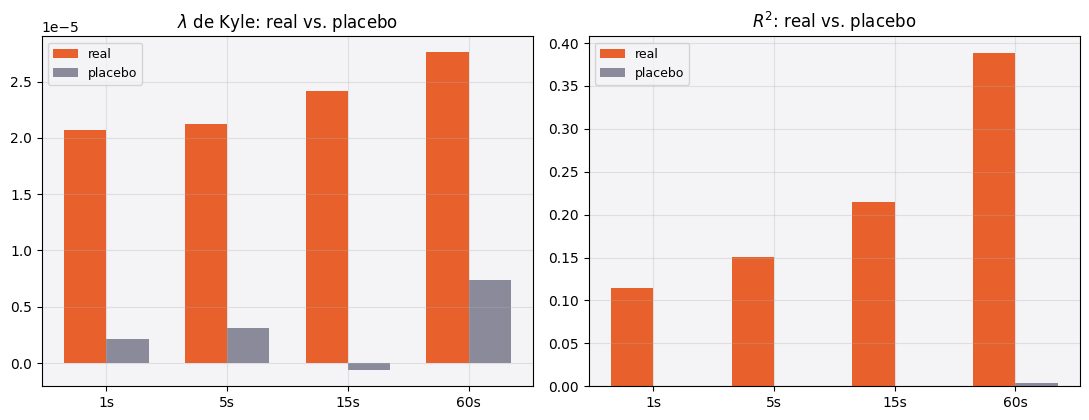

In [6]:
freqs = ['1s', '5s', '15s', '60s']
lam_real = [kyle(f, of_real)[0] for f in freqs]; r2_real = [kyle(f, of_real)[1] for f in freqs]
lam_plac = [kyle(f, of_placebo)[0] for f in freqs]; r2_plac = [kyle(f, of_placebo)[1] for f in freqs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
x = np.arange(len(freqs)); w = 0.35
ax1.bar(x-w/2, lam_real, width=w, color=ORANGE, label='real'); ax1.bar(x+w/2, lam_plac, width=w, color=MGRAY, label='placebo')
ax1.set_xticks(x); ax1.set_xticklabels(freqs); ax1.set_title(r'$\lambda$ de Kyle: real vs. placebo'); ax1.legend(fontsize=9)
ax2.bar(x-w/2, r2_real, width=w, color=ORANGE, label='real'); ax2.bar(x+w/2, r2_plac, width=w, color=MGRAY, label='placebo')
ax2.set_xticks(x); ax2.set_xticklabels(freqs); ax2.set_title(r'$R^2$: real vs. placebo'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
# Ejercicio 2: Avellaneda-Stoikov sobre el camino REAL de AAPL

## La idea

Implementamos las fórmulas de la teórica (precio de reserva y spread óptimo, §4) y las
enfrentamos contra un MM ingenuo (spread fijo, ciego al inventario) — pero esta vez
cotizando sobre el mid-price REAL de AAPL, con fills que ocurren solo si un trade REAL
cruzó la cotización. Nada de un browniano inventado.

**Calibración, 100% con números medidos (no elegidos a mano):**
- $\sigma$ = volatilidad REALIZADA del mid real (desvío de los incrementos a 1s).
- $k$ se calibra para que el spread PROMEDIO de A-S sea igual al spread REAL observado en el Ejercicio 1.
- $A$ = tasa REAL de arribo de trades (por lado).
- $\gamma$ (aversión al riesgo) es el único "dial" libre — es una preferencia del market maker, no algo que esté en los datos.

$$r = S - q\gamma\sigma^2(T-t) \qquad \delta^* = \gamma\sigma^2(T-t) + \frac{2}{\gamma}\ln\left(1+\frac{\gamma}{k}\right)$$

**Sobre la "distribución de 1.000 días":** solo tenemos UN día real. En vez de inventar
999 más, corremos la estrategia en 160 ventanas reales de 10 minutos, cada una empezando
30s después de la anterior (se solapan) — el análogo de "muchas semillas" cuando lo único
que hay es un día real.

In [7]:
mid_1s = mid.resample('1s').last().ffill()
SIGMA = mid_1s.diff().dropna().std()
N = len(mid_1s)
GAMMA = 1e-3   # el "dial" de aversión al riesgo: una preferencia, no un número medido

f_k = lambda k: GAMMA*SIGMA**2*(N/2) + (2/GAMMA)*np.log(1+GAMMA/k) - spread.mean()
K = brentq(f_k, 1e-3, 1e6)
A = (len(tr) / N) / 2   # tasa real de trades, por lado

print(f'σ (realizada, $/√s): {SIGMA:.5f}')
print(f'k (calibrado para igualar el spread real): {K:.3f}')
print(f'A (tasa real de trades por lado, /s): {A:.3f}')
print(f'Chequeo — spread de A-S a mitad de la ventana con esta calibración: ${GAMMA*SIGMA**2*(N/2)+(2/GAMMA)*np.log(1+GAMMA/K):.4f}  (real: ${spread.mean():.4f})')

σ (realizada, $/√s): 0.04595
k (calibrado para igualar el spread real): 42.684
A (tasa real de trades por lado, /s): 10.526
Chequeo — spread de A-S a mitad de la ventana con esta calibración: $0.0526  (real: $0.0526)


In [8]:
t0 = mid_1s.index[0]
mid_arr = mid_1s.values
tr_sec = tr.copy(); tr_sec['sec'] = (tr_sec.index - t0).total_seconds().astype(int)
buy_by_sec = tr_sec[tr_sec['side']=='B'].groupby('sec')['price'].apply(list).to_dict()
sell_by_sec = tr_sec[tr_sec['side']=='A'].groupby('sec')['price'].apply(list).to_dict()

def correr_ventana(start, W, SPREAD_REF):
    q_as = q_naive = 0; cash_as = cash_naive = 0.0; traj = []
    for i in range(W):
        sec = start + i; t_rest = W - i
        m = mid_arr[sec]
        r = m - q_as*GAMMA*SIGMA**2*t_rest
        spread_as = GAMMA*SIGMA**2*t_rest + (2/GAMMA)*np.log(1+GAMMA/K)
        bid_as, ask_as = r - spread_as/2, r + spread_as/2
        bid_n, ask_n = m - SPREAD_REF/2, m + SPREAD_REF/2
        bs, ss = buy_by_sec.get(sec, []), sell_by_sec.get(sec, [])
        if any(p >= ask_as for p in bs): q_as -= 1; cash_as += ask_as
        if any(p <= bid_as for p in ss): q_as += 1; cash_as -= bid_as
        if any(p >= ask_n for p in bs): q_naive -= 1; cash_naive += ask_n
        if any(p <= bid_n for p in ss): q_naive += 1; cash_naive -= bid_n
        traj.append((m, bid_as, ask_as, bid_n, ask_n, q_as, q_naive, r))
    m_final = mid_arr[start+W-1]
    return cash_as+q_as*m_final, cash_naive+q_naive*m_final, q_as, q_naive, traj

W, STEP = 600, 30
starts = list(range(0, N-W, STEP))
resultados = [correr_ventana(s, W, spread.mean()) for s in starts]
pnl_as = np.array([r[0] for r in resultados]); pnl_naive = np.array([r[1] for r in resultados])
inv_as = np.array([abs(r[2]) for r in resultados]); inv_naive = np.array([abs(r[3]) for r in resultados])

print(f'{len(starts)} ventanas reales de 10 min (solapadas, mismo día)')
print(f'P&L medio:      A-S ${pnl_as.mean():.2f}   |   ingenuo ${pnl_naive.mean():.2f}')
print(f'σ del P&L:      A-S ${pnl_as.std():.2f}   |   ingenuo ${pnl_naive.std():.2f}')
print(f'Sharpe:         A-S {pnl_as.mean()/pnl_as.std():.2f}   |   ingenuo {pnl_naive.mean()/pnl_naive.std():.2f}')
print(f'Inventario mediano |q|: A-S {np.median(inv_as):.0f}   |   ingenuo {np.median(inv_naive):.0f}')

160 ventanas reales de 10 min (solapadas, mismo día)
P&L medio:      A-S $7.97   |   ingenuo $13.52
σ del P&L:      A-S $7.07   |   ingenuo $15.63
Sharpe:         A-S 1.13   |   ingenuo 0.87
Inventario mediano |q|: A-S 12   |   ingenuo 26


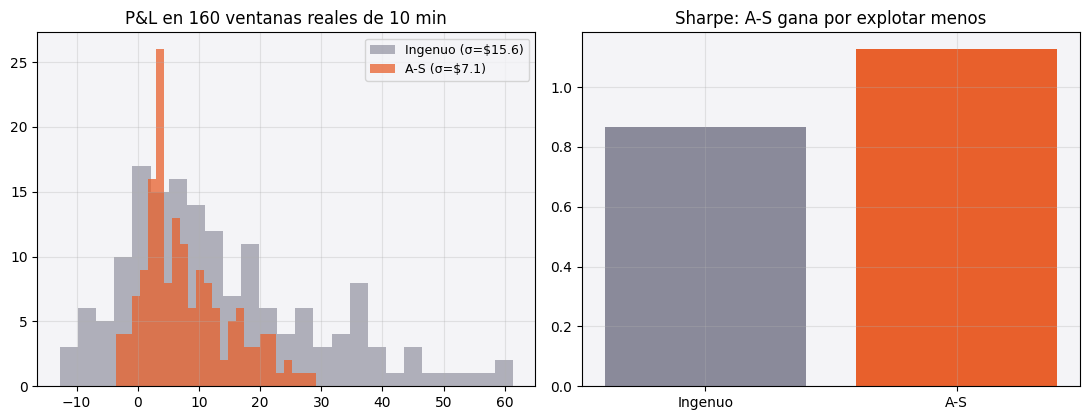

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].hist(pnl_naive, bins=25, color=MGRAY, alpha=0.65, label=f'Ingenuo (σ=${pnl_naive.std():.1f})')
axes[0].hist(pnl_as, bins=25, color=ORANGE, alpha=0.75, label=f'A-S (σ=${pnl_as.std():.1f})')
axes[0].set_title('P&L en 160 ventanas reales de 10 min'); axes[0].legend(fontsize=9)
sh_as, sh_naive = pnl_as.mean()/pnl_as.std(), pnl_naive.mean()/pnl_naive.std()
axes[1].bar(['Ingenuo', 'A-S'], [sh_naive, sh_as], color=[MGRAY, ORANGE])
axes[1].set_title('Sharpe: A-S gana por explotar menos')
plt.tight_layout(); plt.show()

### Una ventana en detalle: ¿por qué se despega el precio de reserva?

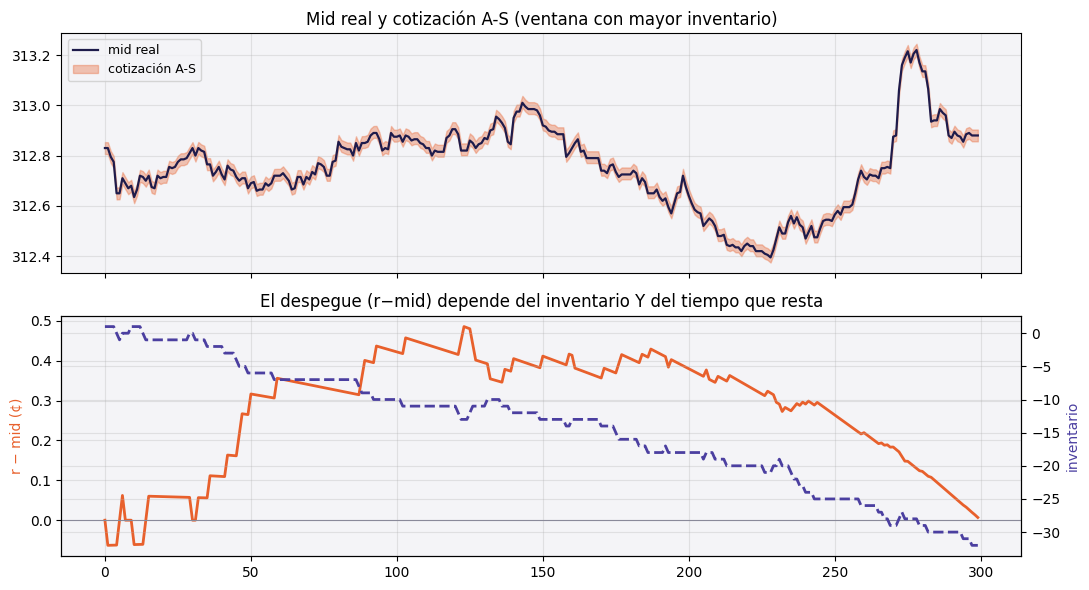

Inventario final: -32 acciones | despegue en ese momento: 0.007¢ (chico: ya casi no queda tiempo)


In [10]:
resultados_5min = [correr_ventana(s, 300, spread.mean()) for s in range(0, N-300, 300)]
idx = int(np.argmax([abs(r[2]) for r in resultados_5min]))
traj = resultados_5min[idx][4]
mids_w = np.array([t[0] for t in traj]); bid_as_w = np.array([t[1] for t in traj]); ask_as_w = np.array([t[2] for t in traj])
q_w = np.array([t[5] for t in traj]); r_w = np.array([t[7] for t in traj])
offset_c = (r_w - mids_w) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
x = np.arange(len(mids_w))
ax1.plot(x, mids_w, color=NAVY, lw=1.6, label='mid real')
ax1.fill_between(x, bid_as_w, ask_as_w, color=ORANGE, alpha=0.35, label='cotización A-S')
ax1.set_title('Mid real y cotización A-S (ventana con mayor inventario)'); ax1.legend(fontsize=9)
ax2b = ax2.twinx()
ax2.plot(x, offset_c, color=ORANGE, lw=2); ax2b.plot(x, q_w, color=VIOLET, lw=2, ls='--')
ax2.axhline(0, color=MGRAY, lw=0.8)
ax2.set_ylabel('r − mid (¢)', color=ORANGE); ax2b.set_ylabel('inventario', color=VIOLET)
ax2.set_title('El despegue (r−mid) depende del inventario Y del tiempo que resta')
plt.tight_layout(); plt.show()
print(f'Inventario final: {q_w[-1]:.0f} acciones | despegue en ese momento: {offset_c[-1]:.3f}¢ (chico: ya casi no queda tiempo)')

---
# Ejercicio 3: Impacto y ejecución, todo calibrado con datos reales

## La idea

Primero reproducimos el fracaso instructivo de la square-root law con la metodología
INGENUA (volumen diario agregado) sobre un panel real de 10 tickers. Después mostramos que
la ley SÍ aparece con la metodología CORRECTA (ráfagas de trades consecutivos del mismo
lado como proxy de una metaorden real + normalización de Tóth et al. 2011), sobre 6
tickers reales intradía. Por último usamos esos números reales — más la $\lambda$ de Kyle
del Ejercicio 1 — para calibrar Almgren-Chriss y ejecutar una orden real de tamaño
realista en AAPL.

In [11]:
TICKERS_NAIVE = ['AAPL','MSFT','JPM','XOM','KO','WMT','JNJ','CAT','DIS','INTC']
B_FALLBACK_30SEP2026 = {  # valores REALES verificados el 30/9/2026 (yfinance, 5 años) — no sintéticos
    'AAPL': 1.364, 'MSFT': 1.304, 'JPM': 1.257, 'XOM': 1.063, 'KO': 0.863,
    'WMT': 0.918, 'JNJ': 0.584, 'CAT': 1.214, 'DIS': 1.004, 'INTC': 1.283,
}
try:
    import yfinance as yf
    data = yf.download(TICKERS_NAIVE, period='5y', progress=False)
    close, vol = data['Close'], data['Volume']
    bs_naive = {}
    for t in TICKERS_NAIVE:
        px = close[t].dropna(); v = vol[t].reindex(px.index).dropna(); px = px.reindex(v.index)
        r = np.log(px/px.shift(1)).dropna()
        vrel = (v/v.rolling(60).mean()).reindex(r.index).dropna(); r = r.reindex(vrel.index).dropna()
        mask = (vrel>0) & (r.abs()>0)
        b, _ = np.polyfit(np.log(vrel[mask]), np.log(r[mask].abs()), 1)
        bs_naive[t] = b
    fuente = 'yfinance, 5 años, en vivo'
except Exception as e:
    bs_naive = dict(B_FALLBACK_30SEP2026)
    fuente = f'fallback con valores REALES verificados el 30/9/2026 (sin conexión: {e})'

print(f'[{fuente}]')
for t, b in bs_naive.items():
    print(f'  {t}: b={b:.3f}')
print(f'Mediana: {np.median(list(bs_naive.values())):.3f}   (predicción teórica: 0.5)')

[yfinance, 5 años, en vivo]
  AAPL: b=1.365
  MSFT: b=1.304
  JPM: b=1.258
  XOM: b=1.063
  KO: b=0.864
  WMT: b=0.920
  JNJ: b=0.584
  CAT: b=1.212
  DIS: b=1.003
  INTC: b=1.282
Mediana: 1.137   (predicción teórica: 0.5)


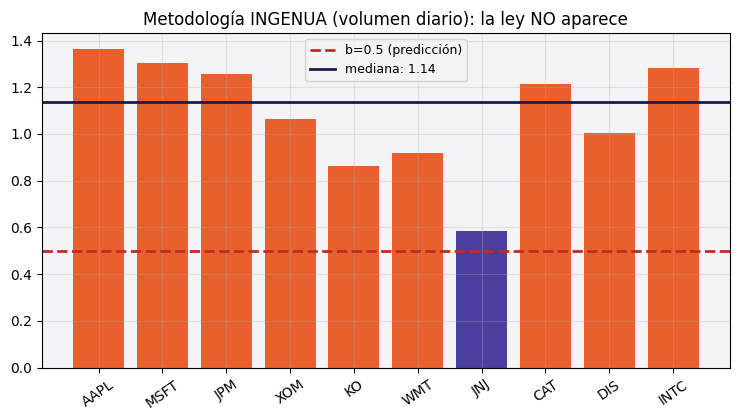

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.3))
tks, vals = list(bs_naive.keys()), list(bs_naive.values())
ax.bar(tks, vals, color=[ORANGE if v>0.8 else VIOLET for v in vals])
ax.axhline(0.5, color=RED, lw=2, ls='--', label='b=0.5 (predicción)')
ax.axhline(np.median(vals), color=NAVY, lw=2, label=f'mediana: {np.median(vals):.2f}')
ax.set_title('Metodología INGENUA (volumen diario): la ley NO aparece'); ax.legend(fontsize=9)
plt.xticks(rotation=35); plt.tight_layout(); plt.show()

In [13]:
TICKERS_TOTH = ['AAPL', 'SPY', 'JPM', 'XOM', 'GME', 'F']
GAP_S, POST_S = 3, 30
allx, ally, por_ticker = [], [], {}
for tk in TICKERS_TOTH:
    bk = pd.read_parquet(os.path.join(DATOS_BOOK, f'{tk}_mbp10_2026-08-06.parquet'))
    tds = pd.read_parquet(os.path.join(DATOS_TRADES, f'{tk}_trades_2026-08-06.parquet'))
    bk = bk[~bk.index.duplicated(keep='last')]
    m_tk = (bk['bid_px_00']+bk['ask_px_00'])/2
    mid_1s_tk = m_tk.resample('1s').last().ffill()
    m1_tk = m_tk.resample('1min').last().ffill()
    sigma_bps = np.log(m1_tk).diff().std() * 1e4
    v_day = tds['size'].sum()

    tr_tk = tds[tds['side'].isin(['A','B'])].copy()
    clusters, cur_side, cur_start, cur_end, cur_size = [], None, None, None, 0
    for t, s, sz in zip(tr_tk.index, tr_tk['side'].values, tr_tk['size'].values):
        if cur_side == s and (t - cur_end) <= pd.Timedelta(seconds=GAP_S):
            cur_end = t; cur_size += sz
        else:
            if cur_side is not None: clusters.append((cur_side, cur_start, cur_end, cur_size))
            cur_side, cur_start, cur_end, cur_size = s, t, t, sz
    if cur_side is not None: clusters.append((cur_side, cur_start, cur_end, cur_size))

    sizes_c, imps_c = [], []
    for side, t0c, t1c, sz in clusters:
        pre = t0c.floor('s') - pd.Timedelta(seconds=1); post = t1c.floor('s') + pd.Timedelta(seconds=POST_S)
        if pre not in mid_1s_tk.index or post not in mid_1s_tk.index: continue
        base = mid_1s_tk.loc[pre]
        if base == 0 or np.isnan(base): continue
        sign = 1 if side == 'B' else -1
        imps_c.append(sign*(mid_1s_tk.loc[post]-base)/base*1e4); sizes_c.append(sz)
    sizes_c, imps_c = np.array(sizes_c), np.array(imps_c)
    q_norm, y_norm = sizes_c/v_day, imps_c/sigma_bps
    qs = np.unique(np.quantile(q_norm, np.linspace(0,1,9)))
    xs_t, ys_t = [], []
    for i in range(len(qs)-1):
        mm = (q_norm>=qs[i]) & (q_norm<qs[i+1])
        if mm.sum() < 10: continue
        xs_t.append(q_norm[mm].mean()); ys_t.append(y_norm[mm].mean())
        allx.append(q_norm[mm].mean()); ally.append(y_norm[mm].mean())
    por_ticker[tk] = (np.array(xs_t), np.array(ys_t), len(clusters))

allx, ally = np.array(allx), np.array(ally)
mask = ally > 0
b_toth, a_toth = np.polyfit(np.log(allx[mask]), np.log(ally[mask]), 1)
print(f'b pooled (metodología correcta, 6 tickers reales intradía) = {b_toth:.3f}')

b pooled (metodología correcta, 6 tickers reales intradía) = 0.528


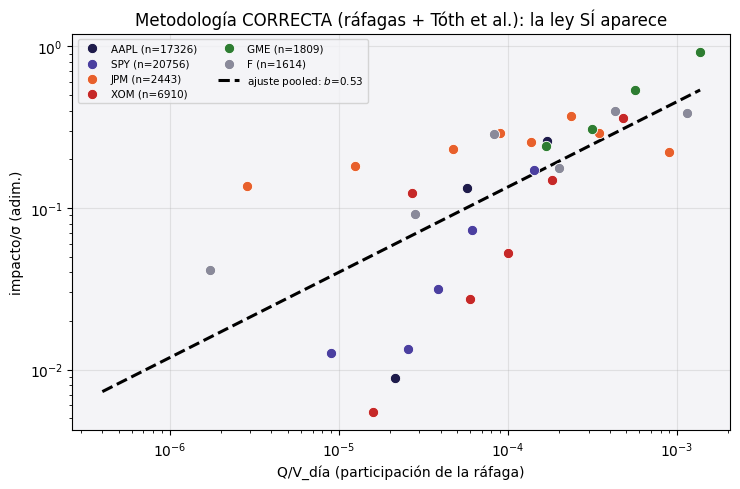

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 5))
colores = [NAVY, VIOLET, ORANGE, RED, GREEN, MGRAY]
for (tk, (q, y, nc)), c in zip(por_ticker.items(), colores):
    mm = y > 0
    ax.scatter(q[mm], y[mm], s=55, color=c, edgecolor='white', linewidth=0.6, label=f'{tk} (n={nc})', zorder=3)
xs = np.linspace(allx.min(), allx.max(), 50)
ax.plot(xs, np.exp(a_toth)*xs**b_toth, color='k', lw=2.2, ls='--', label=fr'ajuste pooled: $b$={b_toth:.2f}', zorder=2)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Q/V_día (participación de la ráfaga)'); ax.set_ylabel('impacto/σ (adim.)')
ax.set_title('Metodología CORRECTA (ráfagas + Tóth et al.): la ley SÍ aparece')
ax.legend(fontsize=7.5, ncol=2); plt.tight_layout(); plt.show()

### Almgren-Chriss, calibrado con AAPL real

$\eta$ (impacto temporario) sale de la $\lambda$ de Kyle real del Ejercicio 1 (freq=60s,
la más estable) — pero hay que reescalarla: $\lambda$ mide impacto por acción agregando en
bloques de 60s, mientras que $\eta$ de Almgren-Chriss mide impacto por una TASA de
acciones/día. Para pasar de uno a otro hay que multiplicar por la fracción de tiempo que
representa ese bloque de 60s dentro de un día de trading (23.400 segundos, 6.5h) — si no,
se comparan dos cosas con la misma unidad nominal ($/acción) pero escalas de tiempo de
referencia distintas, y el "costo" de ejecutar sale disparatado (varios % del notional en
vez de unos pocos puntos básicos).

In [15]:
m60 = mid.resample('60s').last().ffill(); dp60 = m60.diff().dropna()
of60 = of_real.resample('60s').sum()
df60 = pd.concat([dp60, of60], axis=1, keys=['dp','of']).dropna()
lam_kyle_60s, _ = np.polyfit(df60['of'], df60['dp'], 1)

try:
    import yfinance as yf
    d = yf.download('AAPL', period='5y', progress=False)
    vol_a = d['Volume']['AAPL'] if isinstance(d.columns, pd.MultiIndex) else d['Volume']
    close_a = d['Close']['AAPL'] if isinstance(d.columns, pd.MultiIndex) else d['Close']
    ADV = vol_a.median(); PRECIO = close_a.tail(20).mean()
    r_a = np.log(close_a/close_a.shift(1)).dropna()
    SIGMA_DAILY = r_a.std() * PRECIO
    fuente_ac = 'yfinance, en vivo'
except Exception as e:
    ADV, PRECIO, SIGMA_DAILY = 55_170_400.0, 331.27, 5.84
    fuente_ac = f'fallback con valores REALES verificados el 30/9/2026 ({e})'

DAY_SECONDS = 23400.0
ETA = abs(lam_kyle_60s) * 60 / DAY_SECONDS
X, T = 500_000.0, 1.0
notional = X * PRECIO

print(f'[{fuente_ac}]')
print(f'λ de Kyle (60s): {lam_kyle_60s:.3e} $/acción')
print(f'η calibrado (reescalado a 1 día): {ETA:.3e}')
print(f'σ diaria real: ${SIGMA_DAILY:.2f}/acción   ADV real: {ADV:,.0f} acciones')
print(f'Orden a ejecutar: {X:,.0f} acciones (~{X/ADV*100:.2f}% del ADV real), notional ${notional:,.0f}')

def trayectoria(gamma, n=400):
    kappa = np.sqrt(gamma*SIGMA_DAILY**2/ETA)
    t = np.linspace(0, T, n)
    x = X*np.sinh(kappa*(T-t))/np.sinh(kappa*T) if kappa*T > 1e-6 else X*(1-t/T)
    return t, x, kappa

def costo_riesgo(gamma):
    t, x, kappa = trayectoria(gamma)
    v = -np.gradient(x, t); dt = t[1]-t[0]
    return ETA*np.sum(v**2)*dt, SIGMA_DAILY**2*np.sum(x**2)*dt

gammas = np.logspace(-10, -6, 6)
for g in gammas:
    c, rr = costo_riesgo(g)
    print(f'  γ={g:.0e}:  costo=${c:,.0f} ({c/notional*1e4:.1f} bps)   riesgo(Var $²)={rr:.2e}')

[yfinance, en vivo]
λ de Kyle (60s): 2.759e-05 $/acción
η calibrado (reescalado a 1 día): 7.074e-08
σ diaria real: $5.84/acción   ADV real: 55,170,400 acciones
Orden a ejecutar: 500,000 acciones (~0.91% del ADV real), notional $165,676,499
  γ=1e-10:  costo=$17,731 (1.1 bps)   riesgo(Var $²)=2.84e+12
  γ=6e-10:  costo=$17,767 (1.1 bps)   riesgo(Var $²)=2.74e+12
  γ=4e-09:  costo=$18,792 (1.1 bps)   riesgo(Var $²)=2.28e+12
  γ=3e-08:  costo=$31,512 (1.9 bps)   riesgo(Var $²)=1.22e+12
  γ=2e-07:  costo=$78,959 (4.8 bps)   riesgo(Var $²)=4.99e+11
  γ=1e-06:  costo=$204,135 (12.3 bps)   riesgo(Var $²)=2.05e+11


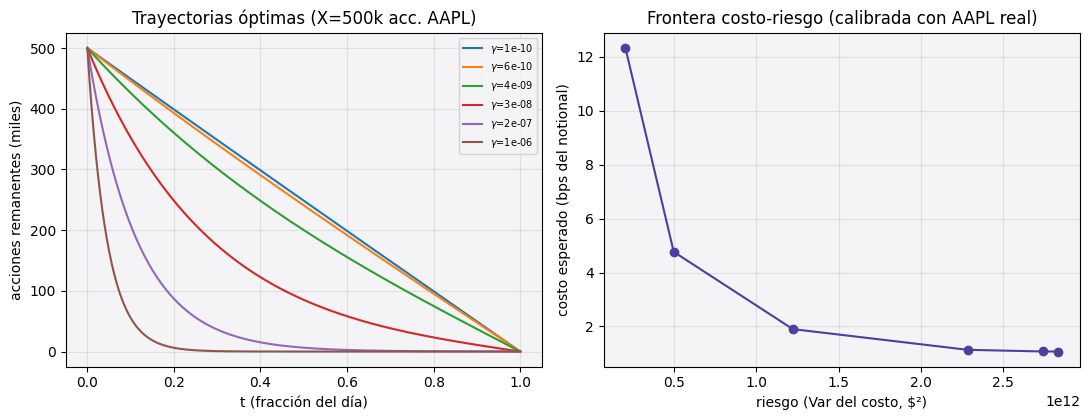

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for g in gammas:
    t, x, kappa = trayectoria(g)
    axes[0].plot(t, x/1000, label=fr'$\gamma$={g:.0e}')
axes[0].set_title(f'Trayectorias óptimas (X={X/1000:.0f}k acc. AAPL)'); axes[0].set_xlabel('t (fracción del día)')
axes[0].set_ylabel('acciones remanentes (miles)'); axes[0].legend(fontsize=7)
costos = [costo_riesgo(g)[0] for g in gammas]; riesgos = [costo_riesgo(g)[1] for g in gammas]
axes[1].plot(riesgos, [c/notional*1e4 for c in costos], 'o-', color=VIOLET)
axes[1].set_title('Frontera costo-riesgo (calibrada con AAPL real)')
axes[1].set_xlabel('riesgo (Var del costo, $²)'); axes[1].set_ylabel('costo esperado (bps del notional)')
plt.tight_layout(); plt.show()

---
# Extra: Hawkes en el order flow real de AAPL

## La idea

Estimamos el branching ratio $n=\alpha/\beta$ por máxima verosimilitud (recursión de
Ozaki, 1979) directamente sobre los timestamps REALES de los ~114.000 trades
direccionales de AAPL del día completo — no sobre un Hawkes simulado. Después comparamos
visualmente contra un Poisson homogéneo de la MISMA tasa LOCAL real, para que la única
diferencia que se vea sea el clustering, no el nivel de actividad.

$$\lambda(t) = \mu + \sum_{t_i<t}\alpha e^{-\beta(t-t_i)} \qquad n = \frac{\alpha}{\beta} < 1$$

In [17]:
tr_full = trades[trades['side'].isin(['A','B'])]
t0_full = tr_full.index.min()
tiempos = np.sort((tr_full.index - t0_full).total_seconds().values)
tiempos = tiempos[tiempos > 0]
T_full = tiempos[-1]
print(f'{len(tiempos):,} eventos direccionales, día completo (T={T_full:.0f}s ≈ {T_full/3600:.1f}h)')

def negloglik_hawkes(params, tiempos, T):
    mu, alpha, beta = params
    if mu<=0 or alpha<=0 or beta<=0 or alpha>=beta: return 1e10
    R, log_lik, t_prev = 0.0, 0.0, 0.0
    for i in range(len(tiempos)):
        R = np.exp(-beta*(tiempos[i]-t_prev))*(1+R) if i>0 else 0.0
        log_lik += np.log(mu+alpha*R); t_prev = tiempos[i]
    integral = mu*T + (alpha/beta)*np.sum(1-np.exp(-beta*(T-tiempos)))
    return -(log_lik-integral)

t0_fit = time.time()
res = minimize(negloglik_hawkes, [1.0,3.0,4.0], args=(tiempos, T_full), method='Nelder-Mead',
               options={'xatol':1e-5,'fatol':1e-5,'maxiter':3000})
mu_hat, alpha_hat, beta_hat = res.x; n_hat = alpha_hat/beta_hat
print(f'Ajuste en {time.time()-t0_fit:.1f}s — μ̂={mu_hat:.3f}  α̂={alpha_hat:.1f}  β̂={beta_hat:.1f}')
print(f'Branching ratio estimado: n̂ = {n_hat:.3f}  (0 = Poisson puro, 1 = inestable)')
print(f'Tasa media real (día completo): {len(tiempos)/T_full:.2f} trades/s')

113,683 eventos direccionales, día completo (T=23400s ≈ 6.5h)
Ajuste en 45.9s — μ̂=1.893  α̂=58523.9  β̂=95889.9
Branching ratio estimado: n̂ = 0.610  (0 = Poisson puro, 1 = inestable)
Tasa media real (día completo): 4.86 trades/s


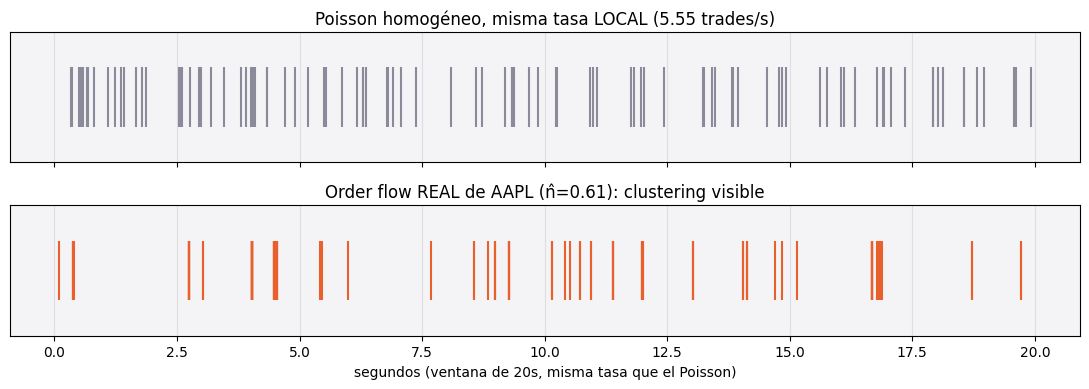

In [18]:
CENTRO, ANCHO = 3600.0, 20.0   # 1h después de la apertura, no la apertura misma (ráfaga atípica de la subasta)
eventos_real_ventana = tiempos[(tiempos>=CENTRO)&(tiempos<CENTRO+ANCHO)] - CENTRO
tasa_local = len(eventos_real_ventana)/ANCHO
rng = np.random.default_rng(11)
eventos_poisson = np.sort(rng.uniform(0, ANCHO, rng.poisson(tasa_local*ANCHO)))

fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
axes[0].eventplot(eventos_poisson, color=MGRAY, linelengths=0.8); axes[0].set_yticks([])
axes[0].set_title(f'Poisson homogéneo, misma tasa LOCAL ({tasa_local:.2f} trades/s)')
axes[1].eventplot(eventos_real_ventana, color=ORANGE, linelengths=0.8); axes[1].set_yticks([])
axes[1].set_title(f'Order flow REAL de AAPL (n̂={n_hat:.2f}): clustering visible')
axes[1].set_xlabel(f'segundos (ventana de {ANCHO:.0f}s, misma tasa que el Poisson)')
plt.tight_layout(); plt.show()